In [20]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add the project root to the path so we can import src
sys.path.append(os.path.abspath(os.path.join('..')))

from src.core import *
from src.utils.signal_generator import SignalGenerator
from src.filters import *

# Setup visualization style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (15, 10)
print("Project Modules Loaded Successfully.")

Project Modules Loaded Successfully.


In [21]:
def visualize_results(results, title, fs):
    """
    Plots:
    1. Time Domain: Raw vs Filtered Signal
    2. Frequency Domain: Spectrum Magnitude vs Filter Mask
    """
    raw_spec = results["original_spectrum"]
    filtered_data = results["output_signal"]
    filter_mask = results.get("filter_mask", None)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, height_ratios=[1, 1])
    
    # 1. Time Domain Plot
    # We need a time axis
    t = np.linspace(0, len(filtered_data)/fs, len(filtered_data))
    
    # Plot a segment (first 1 second or full length)
    limit = min(len(t), int(fs * 2)) 
    
    ax1.set_title(f"{title} - Time Domain Reconstruction")
    ax1.plot(t[:limit], results["raw_signal"][:limit], label='Noisy Input', alpha=0.5, color='red')
    ax1.plot(t[:limit], filtered_data[:limit], label='Denoised Output', color='green', linewidth=1.5)
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Amplitude")
    ax1.legend()
    
    # 2. Frequency Domain Plot
    ax2.set_title(f"{title} - Spectral Analysis")
    ax2.plot(raw_spec.frequencies[:len(raw_spec.frequencies)//2], 
             raw_spec.magnitude[:len(raw_spec.frequencies)//2], 
             label='Original Spectrum', color='gray', alpha=0.6)
    
    # If we have the filtered spectrum data available
    filt_mag = np.abs(results["filtered_spectrum_data"])
    ax2.plot(raw_spec.frequencies[:len(raw_spec.frequencies)//2], 
             filt_mag[:len(raw_spec.frequencies)//2], 
             label='Filtered Spectrum', color='blue', linestyle='--')

    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("Magnitude")
    ax2.set_xlim(0, fs/2) # Nyquist limit
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

Generated ECG Signal with 1440 samples.
Initial SNR: 4.65 dB
Final SNR:   -7.17 dB
Improvement: -11.82 dB


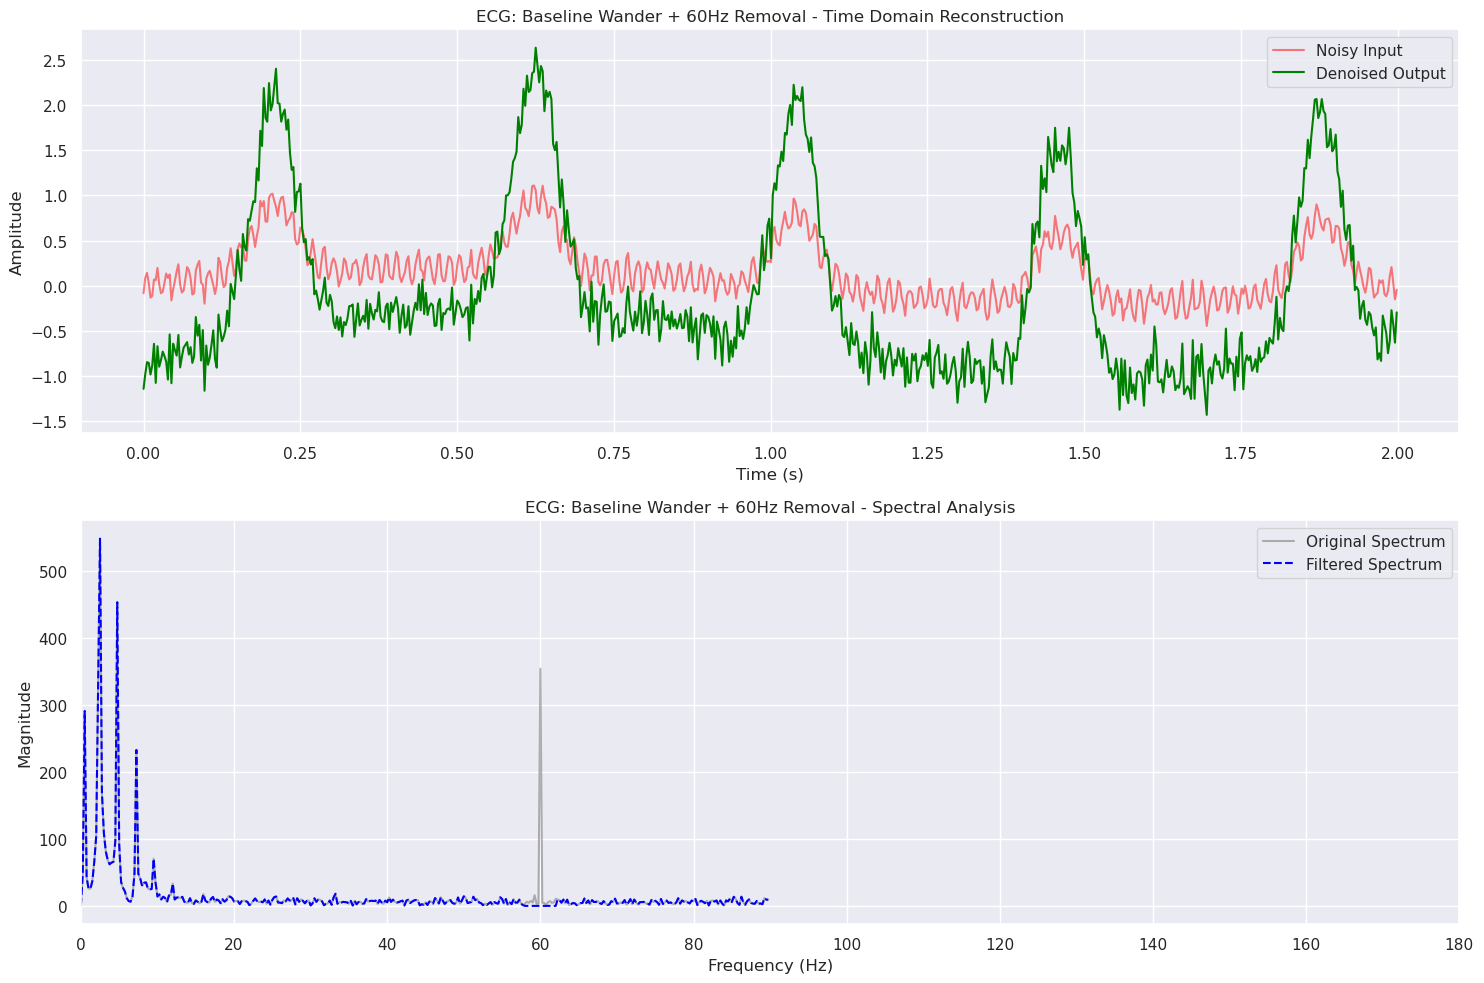

In [22]:
# 1. Generate Synthetic ECG Data
fs = 360.0  # Standard ECG sampling rate
duration = 4.0
gen = SignalGenerator(fs, duration)

t, raw_ecg, clean_ecg = gen.generate_synthetic_ecg()

print(f"Generated ECG Signal with {len(raw_ecg)} samples.")

# 2. Define Pipeline
# We need two filters: Highpass (remove wander) + Notch (remove mains hum)
# Since our basic pipeline takes one filter object, we apply them sequentially or create a CompositeFilter.
# For this demo, we will run the pipeline twice.

pipeline = SignalPipeline(fs)

# Step A: Remove Baseline Wander (Highpass > 0.5Hz)
hp_filter = HighPassFilter(cutoff_freq=0.5, order=2)
res_hp = pipeline.run(raw_ecg, filter_object=hp_filter)
signal_step_1 = res_hp["output_signal"]

# Step B: Remove 60Hz Hum (Notch at 60Hz)
notch_filter = NotchFilter(center_freq=60, bandwidth=4.0)
final_res = pipeline.run(signal_step_1, filter_object=notch_filter)

# Add raw signal to results for visualization
final_res["raw_signal"] = raw_ecg

# 3. Calculate Metrics [cite: 18]
initial_snr = pipeline.reconstructor.calculate_snr(clean_ecg, raw_ecg - clean_ecg)
final_snr = pipeline.reconstructor.calculate_snr(clean_ecg, final_res["output_signal"] - clean_ecg)

print(f"Initial SNR: {initial_snr:.2f} dB")
print(f"Final SNR:   {final_snr:.2f} dB")
print(f"Improvement: {final_snr - initial_snr:.2f} dB")

# 4. Visualize
visualize_results(final_res, "ECG: Baseline Wander + 60Hz Removal", fs)

In [23]:
# 1. Generate Seismic Data


fs = 100.0 # Standard Seismic sampling
duration = 10.0
gen = SignalGenerator(fs, duration)

t, raw_seismic, clean_p_wave = gen.generate_seismic_event()

# 2. Configure Pipeline with Bandpass Filter
# P-waves are often in 1-10Hz range, noise is often broadband or wind (low freq)
pipeline = SignalPipeline(fs)
bp_filter = BandPassFilter(low_cutoff=2.0, high_cutoff=8.0)

# 3. Run Processing
res_seismic = pipeline.run(raw_seismic, filter_object=bp_filter)
res_seismic["raw_signal"] = raw_seismic

# 4. Metrics
mse_before = np.mean((raw_seismic - clean_p_wave)**2)
mse_after = pipeline.reconstructor.calculate_mse(clean_p_wave, res_seismic["output_signal"])

print(f"MSE Before: {mse_before:.5f}")
print(f"MSE After:  {mse_after:.5f}") # Should be significantly lower [cite: 70]

# 5. Visualize
visualize_results(res_seismic, "Seismic P-Wave Extraction (Bandpass 2-8Hz)", fs)

NameError: name 'BandPassFilter' is not defined

In [ ]:
# 1. Generate Audio-like signal (Multi-tone) with heavy White Noise


fs = 44100.0
gen = SignalGenerator(fs, duration=0.05) # Short segment

# Create a composite signal (e.g., a chord)
tone1 = gen.sine_wave(440, 0.5)
tone2 = gen.sine_wave(880, 0.3)
clean_audio = tone1 + tone2
noise = gen.white_noise(0.4)
raw_audio = clean_audio + noise

# 2. Apply Adaptive Spectral Subtraction
pipeline = SignalPipeline(fs)
# factor=2.0 means we subtract 2x the estimated noise floor
adaptive_filter = SpectralSubtractionFilter(noise_floor_factor=2.0) 

res_adaptive = pipeline.run(raw_audio, filter_object=adaptive_filter)
res_adaptive["raw_signal"] = raw_audio

# 3. Visualize
# Note the "Reduction" in the noise floor in the frequency plot
visualize_results(res_adaptive, "Adaptive Spectral Subtraction", fs)

ModuleNotFoundError: No module named 'Side_Projects'

In [26]:
import pandas as pd

data = {
    "Experiment": ["Biomedical (ECG)", "Seismic (P-wave)", "Adaptive Audio"],
    "Filter Type": ["Highpass + Notch", "Bandpass", "Spectral Subtraction"],
    "Metric": ["SNR (dB)", "MSE", "Noise Reduction"],
    "Result": [
        f"+{final_snr - initial_snr:.1f} dB", 
        f"-{(mse_before - mse_after)/mse_before*100:.1f}% Error", 
        "Qualitative"
    ]
}

df = pd.DataFrame(data)
display(df)

NameError: name 'mse_before' is not defined